In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [7]:
df = sns.load_dataset("taxis")
df.head()



,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [8]:
df.info()
df.shape


<class 'pandas.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[us]
 1   dropoff          6433 non-null   datetime64[us]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   str           
 9   payment          6389 non-null   str           
 10  pickup_zone      6407 non-null   str           
 11  dropoff_zone     6388 non-null   str           
 12  pickup_borough   6407 non-null   str           
 13  dropoff_borough  6388 non-null   str           
dtypes: datetime64[us](2), float64(5), int64(1), str(6)


(6433, 14)

In [9]:
df.isnull().sum()


pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64

In [10]:
missing = df.isnull().sum()

missing[missing > 0]


payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64

In [16]:
numerical_columns = df.select_dtypes(include=np.number).columns

categorical_columns = df.select_dtypes(
    include=["object", "string","category"]
).columns

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)


Numerical columns:
Index(['passengers', 'distance', 'fare', 'tip', 'tolls', 'total'], dtype='str')

Categorical columns:
Index(['color', 'payment', 'pickup_zone', 'dropoff_zone', 'pickup_borough',
       'dropoff_borough'],
      dtype='str')


In [18]:
for col in numerical_columns:
    df[col] = df[col].fillna(df[col].median())


In [19]:
for col in categorical_columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])


In [20]:
df.isnull().sum()


pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64

In [22]:
df["pickup"] = pd.to_datetime(df["pickup"])


In [23]:
df["pickup"].dtype


dtype('<M8[us]')

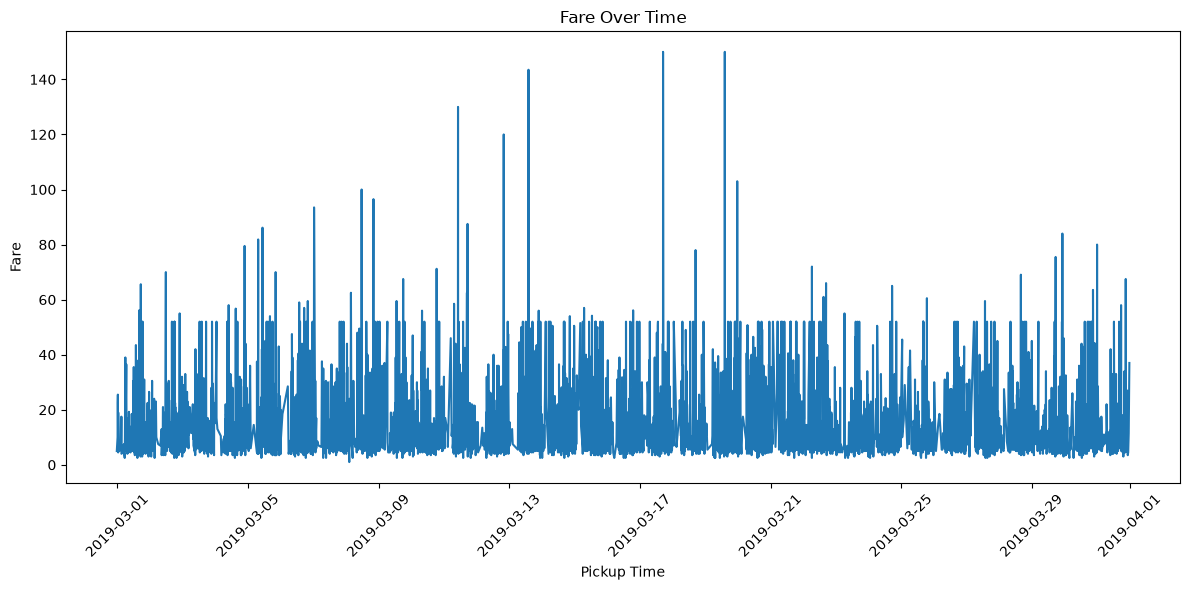

In [25]:
df = df.sort_values("pickup")
plt.figure(figsize=(12, 6))

plt.plot(df["pickup"], df["fare"])

plt.title("Fare Over Time")
plt.xlabel("Pickup Time")
plt.ylabel("Fare")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



In [26]:
borough_fare = df.groupby("pickup_borough")["fare"].sum()

borough_fare


pickup_borough
Bronx         2078.91
Brooklyn      6327.48
Manhattan    59426.42
Queens       16382.06
Name: fare, dtype: float64

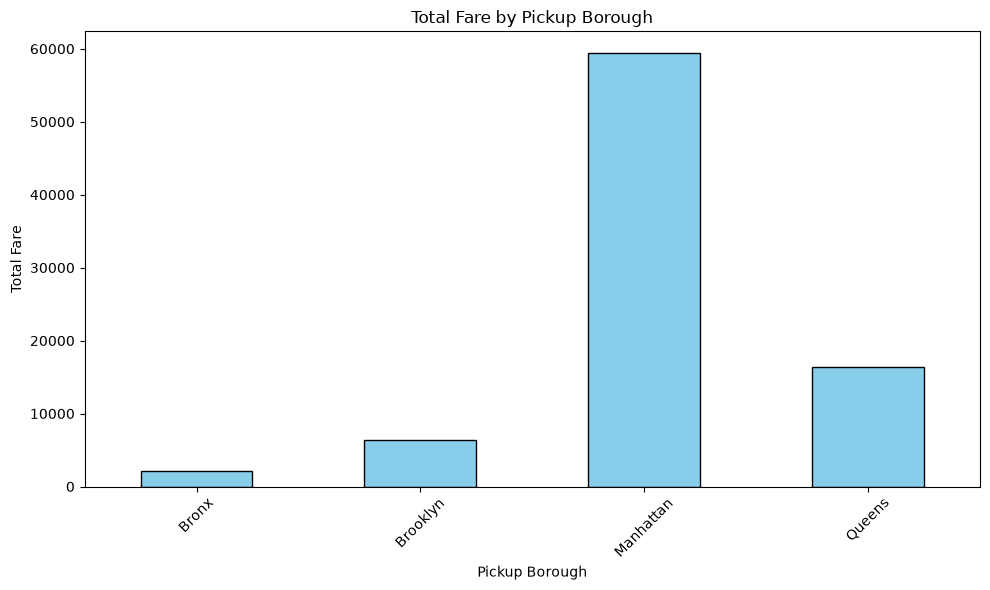

In [27]:
plt.figure(figsize=(10, 6))

borough_fare.plot(
    kind="bar",
    color="skyblue",
    edgecolor="black"
)

plt.title("Total Fare by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Total Fare")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [28]:
payment_counts = df["payment"].value_counts()

payment_counts


payment
credit card    4621
cash           1812
Name: count, dtype: int64

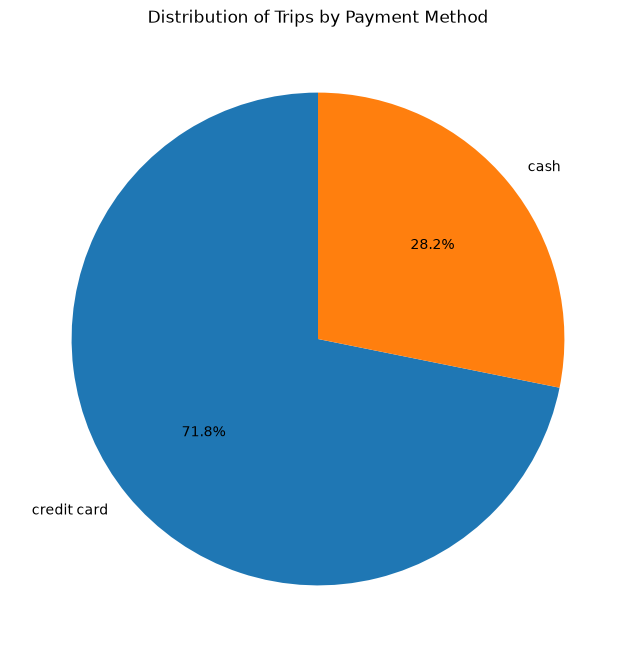

In [29]:
plt.figure(figsize=(8, 8))

plt.pie(
    payment_counts,
    labels=payment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Trips by Payment Method")

plt.show()


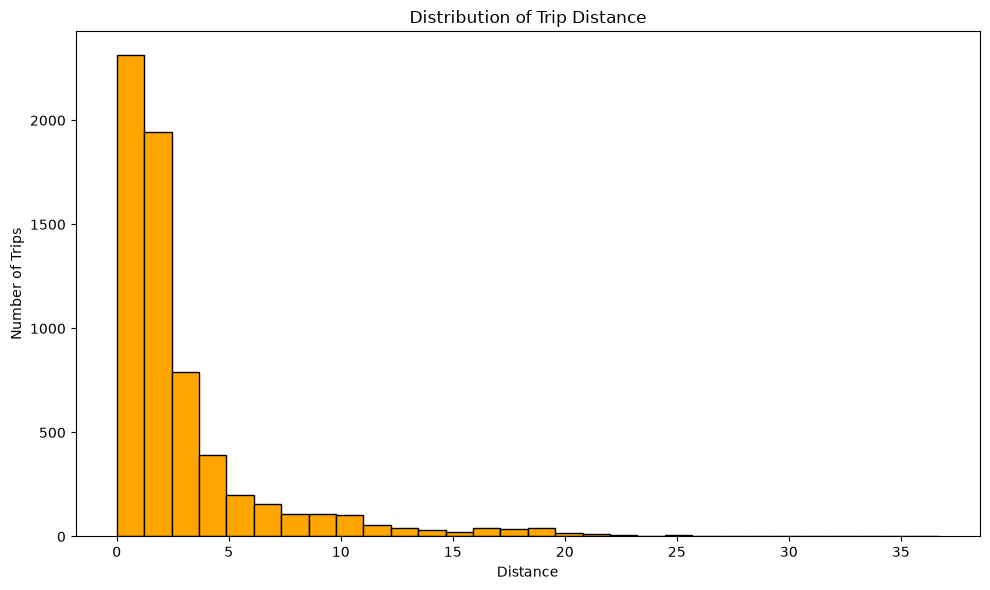

In [30]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["distance"],
    bins=30,
    color="orange",
    edgecolor="black"
)

plt.title("Distribution of Trip Distance")
plt.xlabel("Distance")
plt.ylabel("Number of Trips")

plt.tight_layout()
plt.show()


In [31]:
bins=30


<Figure size 1000x600 with 0 Axes>

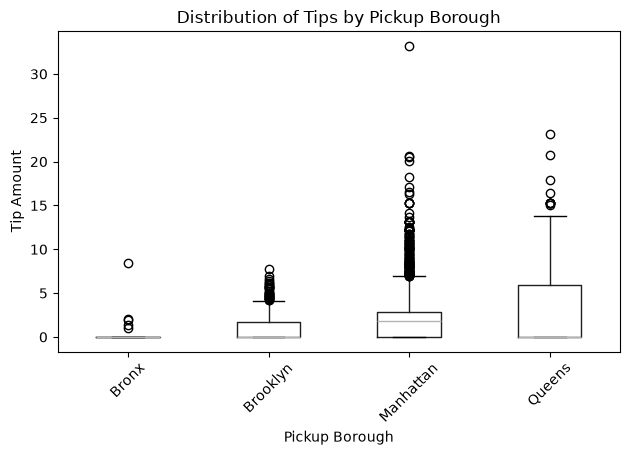

In [32]:
plt.figure(figsize=(10, 6))

df.boxplot(
    column="tip",
    by="pickup_borough",
    grid=False
)

plt.title("Distribution of Tips by Pickup Borough")
plt.suptitle("")

plt.xlabel("Pickup Borough")
plt.ylabel("Tip Amount")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


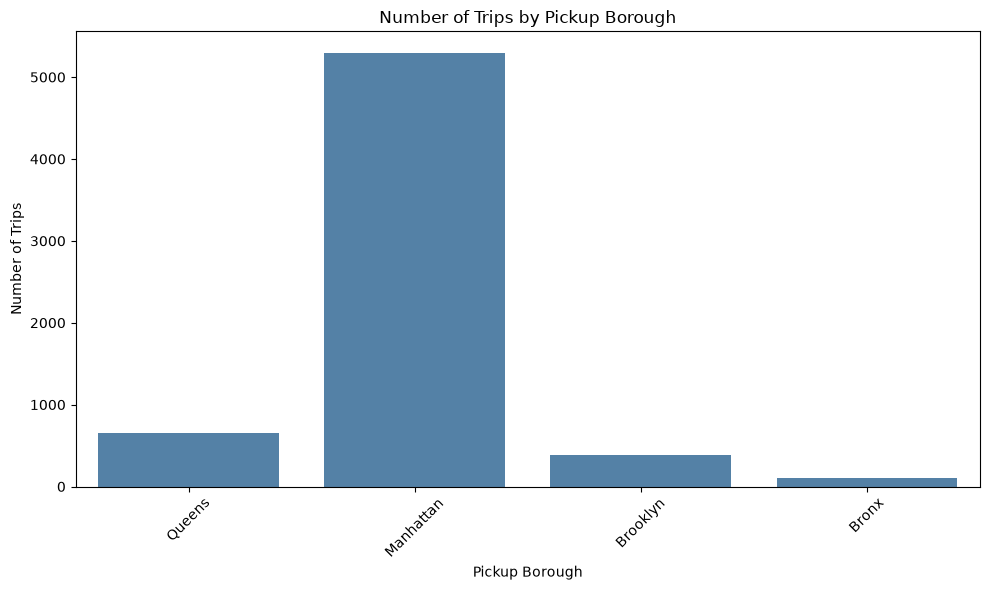

In [33]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="pickup_borough",
    color="steelblue"
)

plt.title("Number of Trips by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Number of Trips")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


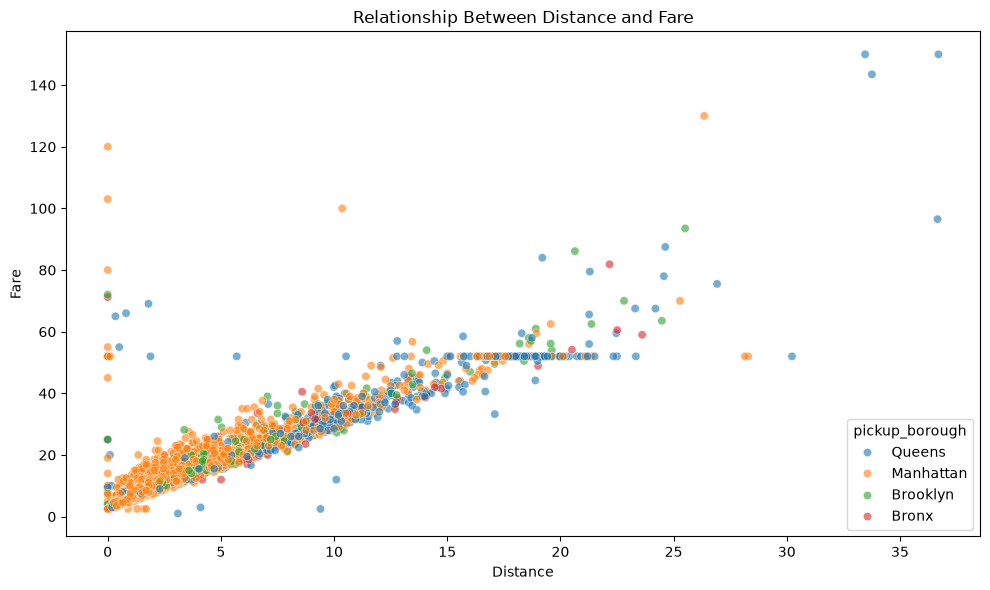

In [34]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="distance",
    y="fare",
    hue="pickup_borough",
    alpha=0.6
)

plt.title("Relationship Between Distance and Fare")
plt.xlabel("Distance")
plt.ylabel("Fare")

plt.tight_layout()
plt.show()


In [35]:
corr_columns = [
    "distance",
    "fare",
    "tip",
    "tolls",
    "total"
]

correlation_matrix = df[corr_columns].corr()

correlation_matrix


,distance,fare,tip,tolls,total
distance,1.000000,0.920108,0.452589,0.635267,0.904676
fare,0.920108,1.000000,0.488612,0.609307,0.974358
tip,0.452589,0.488612,1.000000,0.413619,0.646186
tolls,0.635267,0.609307,0.413619,1.000000,0.683142
total,0.904676,0.974358,0.646186,0.683142,1.000000


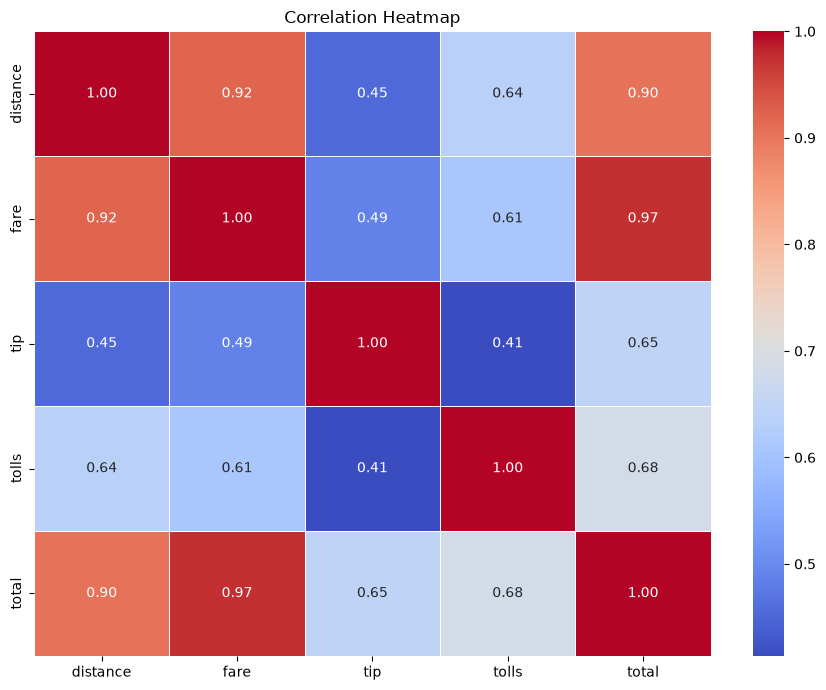

In [36]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()


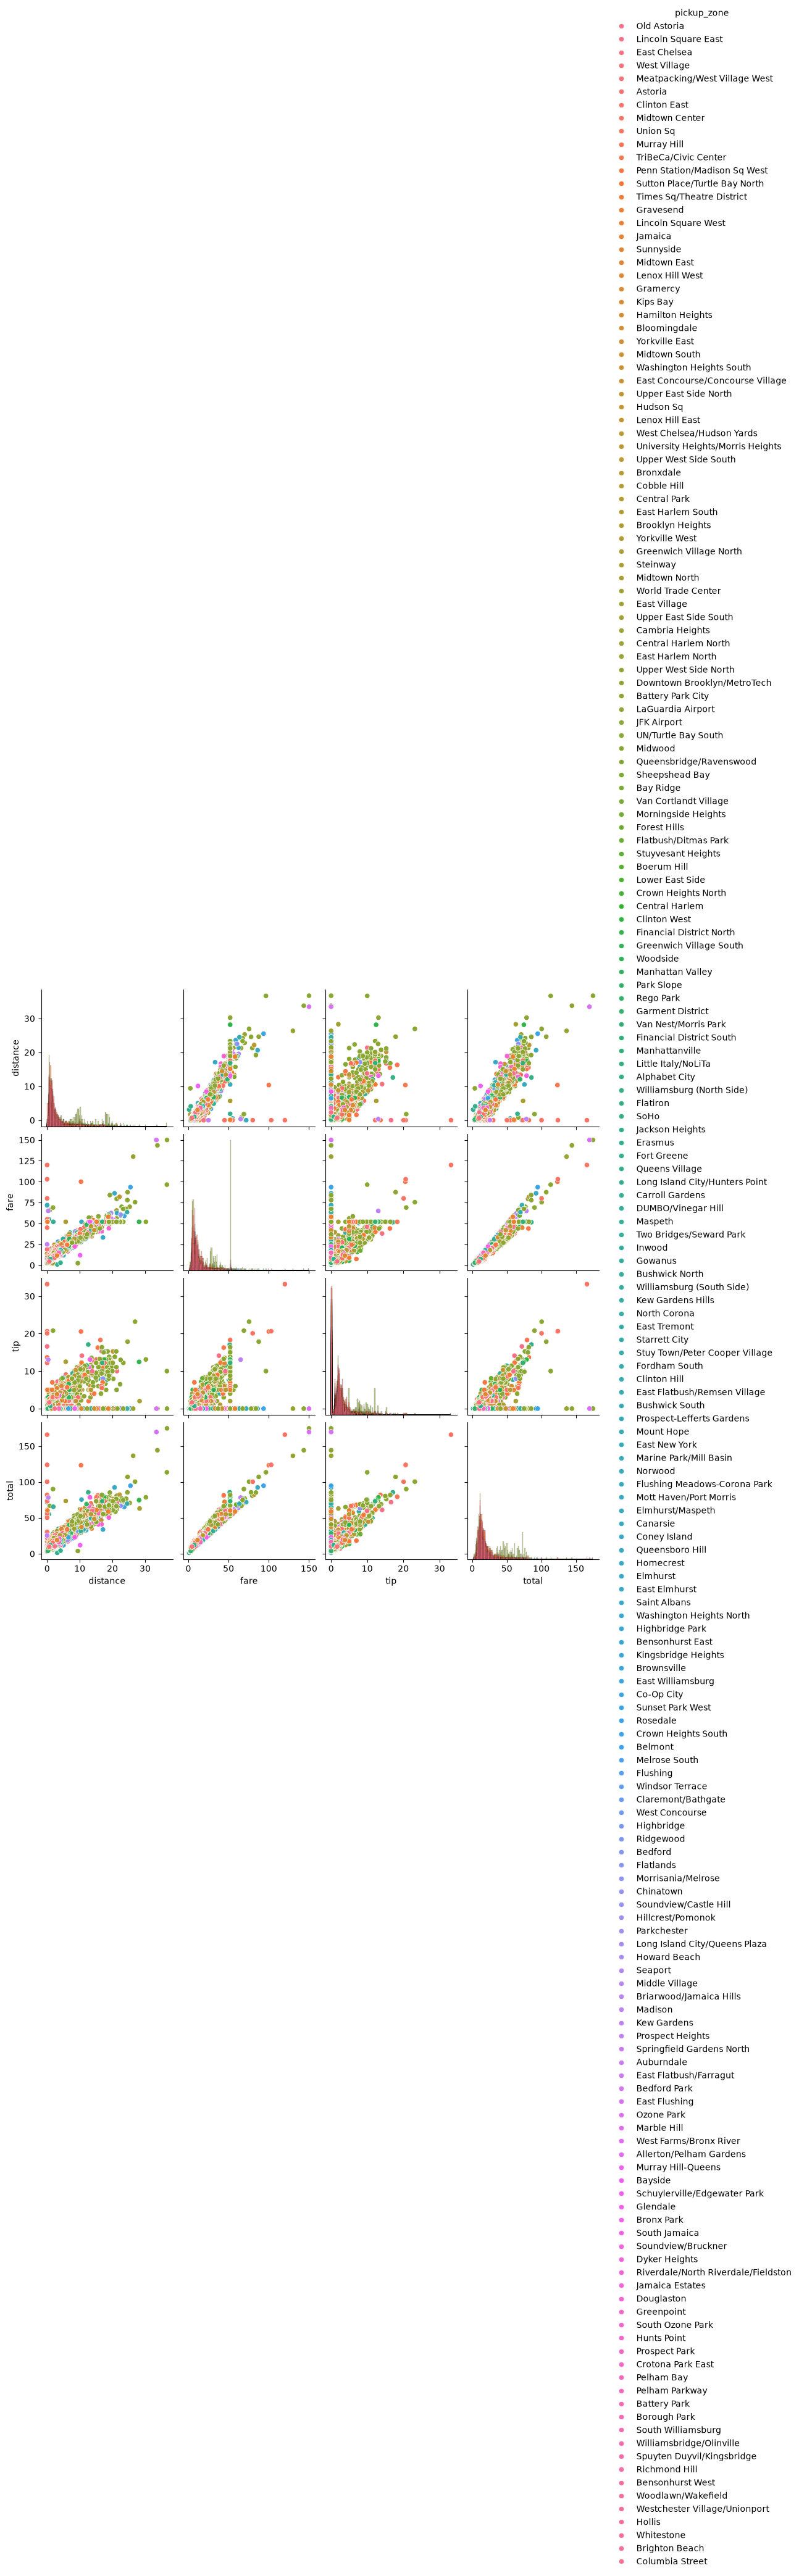

In [38]:
pair_columns = [
    "distance",
    "fare",
    "tip",
    "total",
    "pickup_zone"
]

sns.pairplot(
    df[pair_columns],
    hue="pickup_zone",
    diag_kind="hist"
)

plt.show()


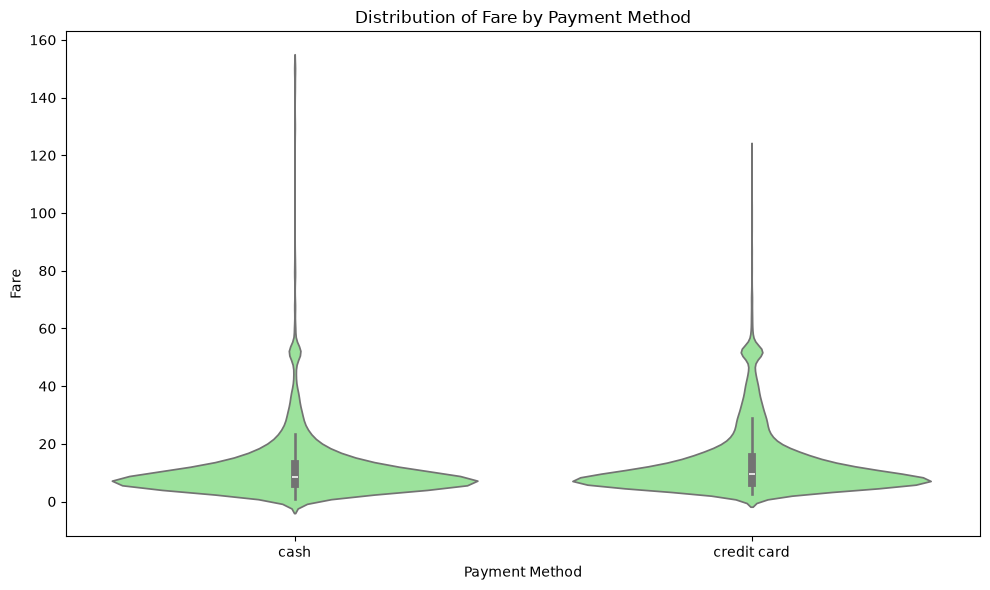

In [39]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df,
    x="payment",
    y="fare",
    color="lightgreen"
)

plt.title("Distribution of Fare by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Fare")

plt.tight_layout()
plt.show()
